<a href="https://colab.research.google.com/github/guilhermef2k/Sistemas_Inteligentes/blob/main/regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1º Projeto - Sistemas inteligentes
Autores: <br>
Alex Bruno Duarte <br>
Guilherme de França Vasconcelos

## 1. Introdução
---

Uma usina termoelétrica de ciclo combinado (UTCC) é uma instalação de alta eficiência que combina turbinas a gás e a vapor para gerar eletricidade. Ela reaproveita o calor dos gases de exaustão da turbina a gás (ciclo Brayton) para produzir vapor em uma caldeira, acionando uma segunda turbina (ciclo Rankine) e aumentando significativamente o rendimento. A principal vantagem é a eficiência energética, que pode chegar a 60%, reduzindo as emissões de gases de efeito estufa. <br>
Embora apresente alta eficiência, o principal desafio técnico no uso de uma usina UTCC reside na integração, sincronização e operação conjunta de dois ciclos termodinâmicos distintos (ciclo Brayton e ciclo Rankine) para funcionar de forma eficiente. Assim sendo, a potência elétrica de saída (PE) é altamente sensível às condições ambientais.

## 2. Objetivo
---

 Construir um modelo matemático de regressão linear múltipla para prever a producão de energia baseando-se em sensores ambientais, permitindo a otimizacão do despacho energético.

## 3. Modelo matemático
---

### 3.1 Conjunto de dados

Para realizar o treinamento do nosso modelo, utilizamos o dataset UCI CCPP (disponível em https://www.kaggle.com/datasets/rinichristy/combined-cycle-power-plant-data-set-uci-data). O dataset contém 9.568 amostras coletadas ao longo de 6 anos. Cada amostra possui as seguintes variáveis:


*   AT (*Ambient Temperature*): Temperatura em °C. Afeta a densidade do ar e a eficiência da combustão.*
*   V (*Exhaust Vacuum*): Vácuo de escape em cm Hg. Relacionado à pressão na turbina a vapor.
*   AP (*Ambient Pressure*): Pressão atmosférica em mbar.
*   RH (*Relative Humidity*): Umidade relativa em percentagem.
*   PE (*Net Hourly Electrical Energy Output*): A variável alvo em MW (MegaWatts).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

In [ ]:
url = 'https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/main/Regress%C3%A3o%20Linear/dataSet/Power%20Plant%20Data.csv'
df = pd.read_csv(url)
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 3.2 Correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE)

In [ ]:
df.corr()["PE"].drop("PE")

,PE
AT,-0.948128
V,-0.869780
AP,0.518429
RH,0.389794


É possível observar que as variáveis AT e V possuem correlação muito forte com a variável PE, portanto tem maior influência na produção de energia. Já as variáveis AP e RH possuem correlação moderada.

### 3.3 Correlação entre as próprias variáveis independentes (AT, V, AP, RH)

In [ ]:
var = ['AT', 'V', 'AP', 'RH']
corr = df[var].corr()
corr

,AT,V,AP,RH
AT,1.000000,0.844107,-0.507549,-0.542535
V,0.844107,1.000000,-0.413502,-0.312187
AP,-0.507549,-0.413502,1.000000,0.099574
RH,-0.542535,-0.312187,0.099574,1.000000


A tabela mostra forte correlação entre a variável V e AT, portanto há multicolineariedade entre elas.  

### 3.4 Modelo de regressão linear múltipla

In [ ]:
X = df.drop(columns=["PE"])
y = df["PE"]

É possível notar que esxiste uma diferença considerável de ordem de grandeza entre as variáveis. Por isso foi adotada a normalização dos dados.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler(feature_range=(0, 1))
scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(scaled, columns=X.columns)
df_scaled.head()

,AT,V,AP,RH
0,0.372521,0.291815,0.771591,0.638204
1,0.662040,0.669039,0.671863,0.449330
2,0.093484,0.249822,0.476862,0.892493
3,0.539660,0.568683,0.429349,0.684718
4,0.255241,0.216014,0.404355,0.952547


Os dados foram divididos em conjuntos de treinamento e teste. O primeiro conjunto representa 80% dos dados e o segundo 20%.

In [ ]:
X = df_scaled
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 9568 amostras
Quantidade de amostras de treinamento = 7654 amostras
Quantidade de amostras de teste = 1914 amostras


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Nesta etapa, instanciamos a regressão linear e apresentamos os dados de treino para que o algoritmo aprenda os pesos de cada variável.

### 3.5 Avaliação de desempenho

Para verificar a eficácia do modelo de regressão linear múltipla, utilizamos métricas estatísticas que quantificam a precisão das previsões em relação aos valores reais observados no conjunto de teste: <br>
Coeficiente de determinação (R^2) e raiz do erro quadrático médio (RMSE)

In [ ]:
r2 = metrics.r2_score(y_test, y_pred)

mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")

R² (Coeficiente de Determinação): 0.9301
RMSE (Raiz do Erro Quadrático Médio): 4.5026


O valor de R^{2} de 0,9301 demonstra que aproximadamente 93% da variabilidade da produção líquida de energia elétrica (PE) é explicada pelas variáveis ambientais (AT, V, AP, RH) captadas pelos sensores. O RMSE de 4,5026 MW indica que, em média, as previsões do modelo se desviam apenas cerca de 4,5 Megawatts do valor real. Considerando que a produção da usina oscila em uma escala significativamente maior, este erro é considerado baixo.

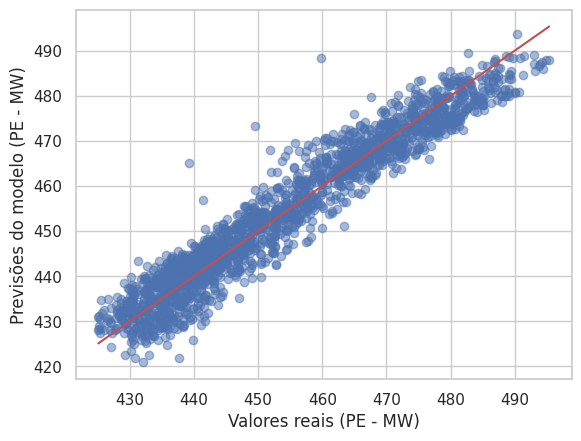

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Valores reais (PE - MW)")
plt.ylabel("Previsões do modelo (PE - MW)")

X_input = np.linspace(y_test.min(), y_test.max(), 1000)
plt.plot(X_input, X_input, "r")

plt.grid(True)
plt.show()

Como observado no gráfico acima, os pontos de dados seguem de forma muito próxima a linha tracejada vermelha. Quanto mais concentrados os pontos estiverem ao redor dessa linha, maior é a precisão do modelo em capturar a relação entre as variáveis ambientais e a potência elétrica produzida.

## 4. Conclusão

O modelo é perfeitamente adequado para prever a produção de energia da UTCC. A alta precisão alcançada confirma que sensores de temperatura, pressão, vácuo e umidade são preditores robustos para a saída de energia. Portanto, o modelo cumpre o objetivo proposto de auxiliar na otimização do despacho energético da planta.